Q1


In [14]:
import pandas as pd

In [15]:
df = pd.read_csv(r"C:\Users\jahna\Downloads\train.csv")

In [16]:
df.head()

,row_id,body,rule,subreddit,positive_example_1,positive_example_2,negative_example_1,negative_example_2,rule_violation
0,0,Banks don't want you to know this! Click here ...,"No Advertising: Spam, referral links, unsolici...",Futurology,If you could tell your younger self something ...,hunt for lady for jack off in neighbourhood ht...,Watch Golden Globe Awards 2017 Live Online in ...,"DOUBLE CEE x BANDS EPPS - ""BIRDS""\n\nDOWNLOAD/...",0
1,1,SD Stream [ ENG Link 1] (http://www.sportsstre...,"No Advertising: Spam, referral links, unsolici...",soccerstreams,[I wanna kiss you all over! Stunning!](http://...,LOLGA.COM is One of the First Professional Onl...,#Rapper \n🚨Straight Outta Cross Keys SC 🚨YouTu...,[15 Amazing Hidden Features Of Google Search Y...,0
2,2,Lol. Try appealing the ban and say you won't d...,No legal advice: Do not offer or request legal...,pcmasterrace,Don't break up with him or call the cops. If ...,It'll be dismissed: https://en.wikipedia.org/w...,Where is there a site that still works where y...,Because this statement of his is true. It isn'...,1
3,3,she will come your home open her legs with an...,"No Advertising: Spam, referral links, unsolici...",sex,Selling Tyrande codes for 3€ to paypal. PM. \n...,tight pussy watch for your cock get her at thi...,NSFW(obviously) http://spankbang.com/iy3u/vide...,Good News ::Download WhatsApp 2.16.230 APK for...,1
4,4,code free tyrande --->>> [Imgur](http://i.imgu...,"No Advertising: Spam, referral links, unsolici...",hearthstone,wow!! amazing reminds me of the old days.Well...,seek for lady for sex in around http://p77.pl/...,must be watch movie https://sites.google.com/s...,We're streaming Pokemon Veitnamese Crystal RIG...,1


In [17]:
df = df[["body", "rule_violation"]].rename(columns={"body": "text", "rule_violation": "label"})

In [18]:
df.label = df.label.map({0: "no_violation", 1: "violation"})

In [19]:

print(df.head())

                                                text         label
0  Banks don't want you to know this! Click here ...  no_violation
1  SD Stream [ ENG Link 1] (http://www.sportsstre...  no_violation
2  Lol. Try appealing the ban and say you won't d...     violation
3  she will come your home open her legs with  an...     violation
4  code free tyrande --->>> [Imgur](http://i.imgu...     violation


In [20]:

print(df.isnull().sum())

text     0
label    0
dtype: int64


In [21]:
percentages = df["label"].value_counts(normalize=True) * 100

In [22]:
print(percentages)

label
violation       50.813208
no_violation    49.186792
Name: proportion, dtype: float64


 Q2)
 F1-score

Imbalanced dataset is where distribution of observation in target class is uneven,Which means one class is significantly higher in number than the other.This might lead to biased predictios as a result favoring the majority class.

Since the dataset is nearly balanced (50% vs 49%), accuracy can be used as the primary evaluation metric, and F1-score can be reported to assess the balance between precision and recall.

Accuracy - Evaluates the overall correctness
F1 - Evaluates the harmonic mean of precision and recall 





Q3

Preprocessing Function

In [23]:
import re
import nltk
nltk.download('wordnet')
nltk.download('omw-1.4')
nltk.download('stopwords')

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\jahna\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\jahna\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\jahna\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [24]:
def preprocess_text(text):
    text = text.lower()
    text = re.sub(r"http\S+|www\S+|https\S+", '', text)
    text = re.sub(r'[^a-z\s]', '', text)
    text = " ".join([lemmatizer.lemmatize(w) for w in text.split() if w not in stop_words])
    return text

In [25]:

df['clean_text'] = df['text'].apply(preprocess_text)

In [26]:
from sklearn.model_selection import train_test_split

In [27]:
X = df['clean_text']
y = df['label']

In [28]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.5, random_state=42, stratify=y
)

In [29]:

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 1014
Testing samples: 1015


TF-IDF Sparse Embedding


In [30]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

In [31]:
tfidf = TfidfVectorizer(max_features=10000, min_df=5, max_df=0.9, ngram_range=(1,2))
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

In [32]:
lr = LogisticRegression(class_weight='balanced', max_iter=1000)
lr.fit(X_train_tfidf, y_train)
y_pred = lr.predict(X_test_tfidf)

In [33]:

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

no_violation       0.72      0.68      0.70       499
   violation       0.71      0.74      0.73       516

    accuracy                           0.71      1015
   macro avg       0.71      0.71      0.71      1015
weighted avg       0.71      0.71      0.71      1015



Feature Engineering Pipeline


In [34]:
import numpy as np
import spacy
from textblob import TextBlob

In [35]:
nlp = spacy.load("en_core_web_sm")

In [38]:
def featurize(text):
    return [len(text), len(text.split())]


In [39]:
X_train_f = np.array(X_train.apply(featurize).tolist())
X_test_f  = np.array(X_test.apply(featurize).tolist())

In [40]:
lr_f = LogisticRegression(class_weight='balanced', max_iter=1000)
lr_f.fit(X_train_f, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [41]:
y_pred_f = lr_f.predict(X_test_f)

In [42]:
print("Feature Engineering Pipeline Performance (50% subset):")
print(classification_report(y_test, y_pred_f))

Feature Engineering Pipeline Performance (50% subset):
              precision    recall  f1-score   support

no_violation       0.57      0.65      0.61       499
   violation       0.61      0.52      0.56       516

    accuracy                           0.59      1015
   macro avg       0.59      0.59      0.59      1015
weighted avg       0.59      0.59      0.59      1015



TF-IDF and Feature Engineering


In [43]:
from scipy.sparse import hstack

In [44]:

X_train_hybrid = hstack([X_train_tfidf, X_train_f])
X_test_hybrid  = hstack([X_test_tfidf, X_test_f])

In [45]:
lr_h = LogisticRegression(class_weight='balanced', max_iter=1000)
lr_h.fit(X_train_hybrid, y_train)


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [46]:
y_pred_h = lr_h.predict(X_test_hybrid)

In [47]:
print("Hybrid Pipeline Performance (50% subset):")
print(classification_report(y_test, y_pred_h))

Hybrid Pipeline Performance (50% subset):
              precision    recall  f1-score   support

no_violation       0.73      0.69      0.71       499
   violation       0.71      0.75      0.73       516

    accuracy                           0.72      1015
   macro avg       0.72      0.72      0.72      1015
weighted avg       0.72      0.72      0.72      1015



In [60]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import learning_curve
from sklearn.utils.validation import check_X_y
import pandas as pd

In [73]:
def plot_learning_curve(estimator, title, X, y, cv=5, n_jobs=-1,
                        train_sizes=np.linspace(0.1, 1.0, 5)):
    train_sizes,train_scores,test_scores = learning_curve(
        estimator, X, y, cv=cv, n_jobs=n_jobs, train_sizes=train_sizes
    )
    train_mean = np.mean(train_scores, axis=1)
    test_mean = np.mean(test_scores, axis=1)
    plt.figure(figsize=(6,4))
    plt.plot(train_sizes, train_mean, 'o-', label="Train")
    plt.plot(train_sizes, test_mean, 'o-', label="CV")
    plt.title(title)
    plt.xlabel("Training examples")
    plt.ylabel("Score")
    plt.legend()
    plt.grid(True)
    plt.show()
    return train_sizes, train_scores, test_scores

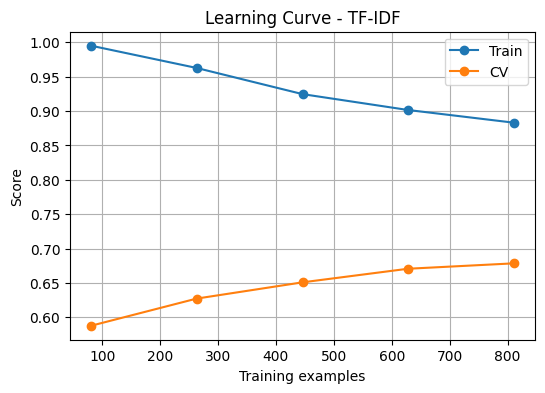

In [74]:
train_sizes_tfidf, train_scores_tfidf, test_scores_tfidf = plot_learning_curve(
    lr, "Learning Curve - TF-IDF", X_train_tfidf, y_train
)
train_mean_tfidf = np.mean(train_scores_tfidf, axis=1)
test_mean_tfidf = np.mean(test_scores_tfidf, axis=1)

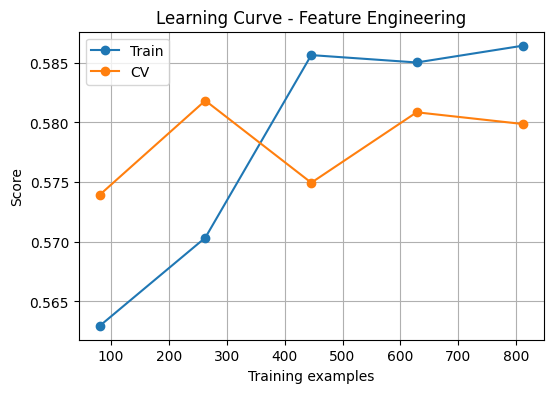

In [76]:
train_sizes_f, train_scores_f, test_scores_f = plot_learning_curve(
    lr_f, "Learning Curve - Feature Engineering", X_train_f, y_train
)
train_mean_f = np.mean(train_scores_f, axis=1)
test_mean_f = np.mean(test_scores_f, axis=1)

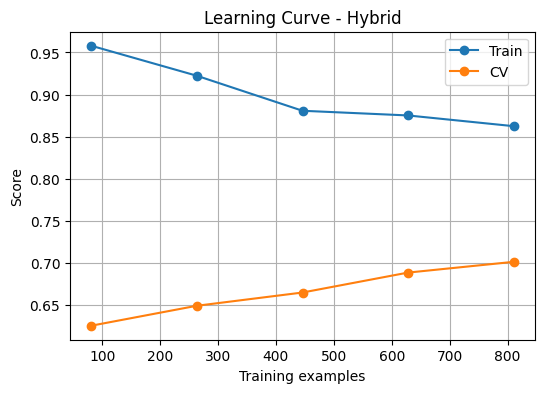

In [77]:
train_sizes_h, train_scores_h, test_scores_h = plot_learning_curve(
    lr_h, "Learning Curve - Hybrid", X_train_hybrid, y_train
)
train_mean_h = np.mean(train_scores_h, axis=1)
test_mean_h = np.mean(test_scores_h, axis=1)

For this dataset, the Hybrid Pipeline shows the strongest performance based on the accuracy score of 0.72 on the 50% subset, indicating a balanced performance across both classes.The Feature Engineering pipeline performs the weakest, with an accuracy of 0.59, suggesting that the handcrafted features alone are insufficient for strong classification.While TF-IDF alone was previously strong, the hybrid pipeline slightly outperforms TF-IDF when combining sparse embeddings with feature engineering.

Overall, using accuracy as the primary metric, the hybrid pipeline is the most suitable for this dataset.